# Report Visualisations — River Flood Hazard and Risk (Building and Population Level)
Loads cached outputs from the GLOFAS hazard and building-level risk notebooks.
Place this script in the same directory as those notebooks and run after both.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.mask import mask as rio_mask
import rioxarray as rxr
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.gridspec as mgs
import contextily as ctx
import warnings
from shapely.geometry import Polygon

warnings.filterwarnings('ignore', category=rasterio.errors.NotGeoreferencedWarning)

In [2]:
# ---------------------------------------------------------------------------
# Configuration — must match hazard and risk notebooks
# ---------------------------------------------------------------------------
SHAPEFILE_PATH   = Path(
    r'C:\Users\dauzo\Models\crabook-kazakhstan\crabook'
    r'\KAZ_BORDER_VERSION_1\LVL3\SHP_LVL3\KAZ_OSM_BORDER_LVL3.shp'
)  # <-- update to your local shapefile path
region_name      = 'Astana'                    # must match hazard notebook
save_name        = 'AlmatyDistrict_Astana'     # must match risk notebook saveName
return_periods   = [10, 50, 100, 200, 500]
return_period_aq = 250
scenarios        = ['rcp4p5', 'rcp8p5']
years_aq         = [2030, 2050, 2080]
Depth            = 'Mean'

# AOI bounding box — must match risk notebook
Latitude1,  Longitude1 = 51.085, 71.438
Latitude2,  Longitude2 = 51.203, 71.785
xbuffer, ybuffer        = 0.005, 0.003

In [3]:
# ---------------------------------------------------------------------------
# Paths — relative to this script (same folder as hazard notebook)
# ---------------------------------------------------------------------------
hazard_data_dir = Path('.') / 'results' / region_name / 'data'
aq_dir          = hazard_data_dir / 'aqueduct_floods'
risk_dir        = Path('.') / 'results' / region_name / 'risk' / save_name
dmg_dir         = risk_dir / 'DamageBuildings'
pop_dir         = risk_dir / 'ExposedPopulation'
osm_dir         = risk_dir / 'OSM'
report_dir      = Path('.') / 'results' / region_name / 'report'
report_dir.mkdir(parents=True, exist_ok=True)

In [4]:
# ---------------------------------------------------------------------------
# Load cached data
# ---------------------------------------------------------------------------
outline = gpd.GeoSeries(
    [Polygon([(Longitude1, Latitude1), (Longitude2, Latitude1),
              (Longitude2, Latitude2), (Longitude1, Latitude2)])],
    crs='EPSG:4326',
)
outline_geoms = list(outline)

aq_base  = xr.open_dataset(
    aq_dir / f'inunriver_historical_000000000WATCH_1980_rp{return_period_aq:05d}_{region_name}.nc')
aq_all   = xr.open_dataset(
    aq_dir / f'inunriver_AllScenarios_ModelMean_AllYears_rp{return_period_aq:05d}_{region_name}.nc')
dmg_csv  = pd.read_csv(dmg_dir / f'{save_name}_DamageTotal_{Depth}.csv', index_col=0)
pop_csv  = pd.read_csv(pop_dir / f'{save_name}_PopulationExposureDisplacement.csv')
osm_gdf  = gpd.read_file(osm_dir / f'{save_name}_OSM_Building_Reclassified.shp')[
               ['bldgClass', 'geometry']]

rp_cols      = [c for c in dmg_csv.columns if '-yr' in c]
classes      = [idx for idx in dmg_csv.index if idx != 'Total']
totals       = dmg_csv.loc['Total', rp_cols].values / 1e6   # million USD
probs        = 1 / np.array(return_periods, dtype=float)
scen_labels  = {'rcp4p5': 'RCP4.5', 'rcp8p5': 'RCP8.5'}
scen_colors  = {'rcp4p5': 'steelblue', 'rcp8p5': 'firebrick'}
class_colors = {'Residential': '#e74c3c', 'Commercial': '#3498db',
                'Industrial': '#f39c12',  'Universal': '#95a5a6'}

print(f'Data loaded. Reports will be saved to: {report_dir}')

Data loaded. Reports will be saved to: results\Astana\report


# Flood Hazard — Present-Day Inundation Depth

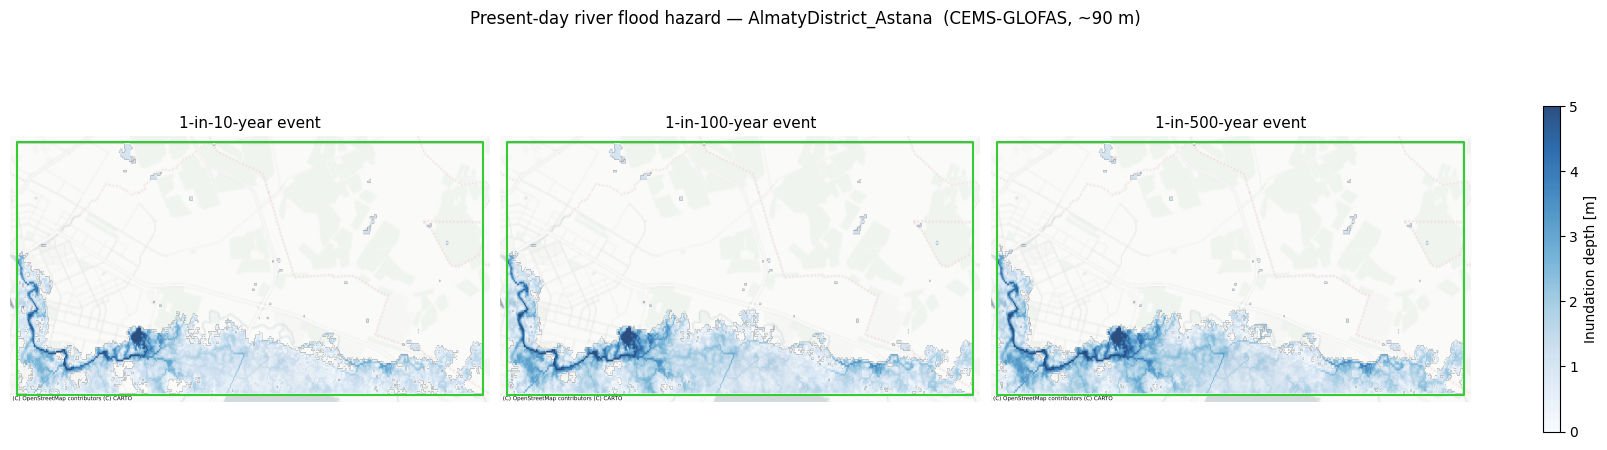

In [7]:
rps_plot = [10, 100, 500]
fig, axs = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True,
                        sharex=True, sharey=True)
for ii, rp in enumerate(rps_plot):
    rast = hazard_data_dir / f'floodmap_GLOFAS_PresentScenario_{region_name}_RP{rp}.tif'
    with rasterio.open(rast) as src:
        clipped, _ = rio_mask(src, outline_geoms, crop=True)
        arr = np.ma.masked_where(
            (clipped[0] < 0) | (clipped[0] > 1000), clipped[0])
    im = axs[ii].imshow(arr, cmap='Blues', vmin=0, vmax=5, alpha=0.85,
                        extent=(Longitude1, Longitude2, Latitude1, Latitude2),
                        zorder=2)
    outline.plot(ax=axs[ii], edgecolor='limegreen', facecolor='none',
                 linewidth=1.5, zorder=5)
    axs[ii].set_xlim(Longitude1 - xbuffer, Longitude2 + xbuffer)
    axs[ii].set_ylim(Latitude1  - ybuffer, Latitude2  + ybuffer)
    ctx.add_basemap(axs[ii], crs='EPSG:4326',
                    source=ctx.providers.CartoDB.Positron, attribution_size=4)
    axs[ii].set_title(f'1-in-{rp}-year event', fontsize=11)
    axs[ii].set_axis_off()
fig.colorbar(im, ax=axs.ravel().tolist(), label='Inundation depth [m]', shrink=0.7)
fig.suptitle(f'Present-day river flood hazard — {save_name}  (CEMS-GLOFAS, ~90 m)', fontsize=12)
fig.savefig(report_dir / 'fig01_hazard_present.png', dpi=150, bbox_inches='tight')
plt.show()

# Flood Depth at Building Locations by Return Period

  Reading building depths RP10...
  Reading building depths RP50...
  Reading building depths RP100...
  Reading building depths RP200...
  Reading building depths RP500...


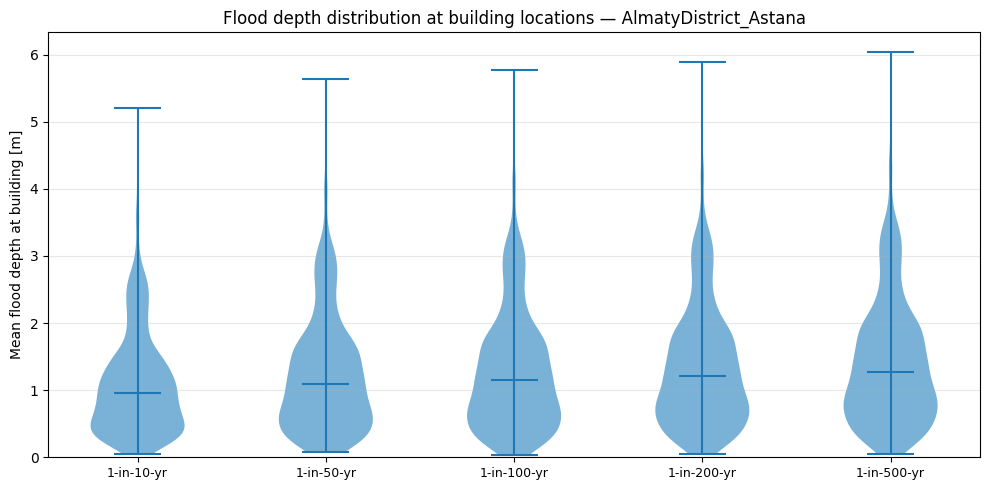

In [8]:
depth_data = []
for rp in return_periods:
    print(f'  Reading building depths RP{rp}...')
    shp  = gpd.read_file(dmg_dir / f'{save_name}_Depths_Building_RP{rp}.shp')
    vals = shp['MeanDepth'].dropna().values
    depth_data.append(vals[vals > 0] if np.any(vals > 0) else np.array([0.0]))

fig, ax = plt.subplots(figsize=(10, 5))
vp = ax.violinplot(depth_data, showmedians=True)
for pc in vp['bodies']:
    pc.set_facecolor('#4292c6')
    pc.set_alpha(0.7)
ax.set_xticks(range(1, len(return_periods) + 1))
ax.set_xticklabels([f'1-in-{rp}-yr' for rp in return_periods], fontsize=9)
ax.set_ylabel('Mean flood depth at building [m]')
ax.set_title(f'Flood depth distribution at building locations — {save_name}')
ax.set_ylim(0)
ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
fig.savefig(report_dir / 'fig02_building_depth_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Projected Flood Depth Change — RCP8.5

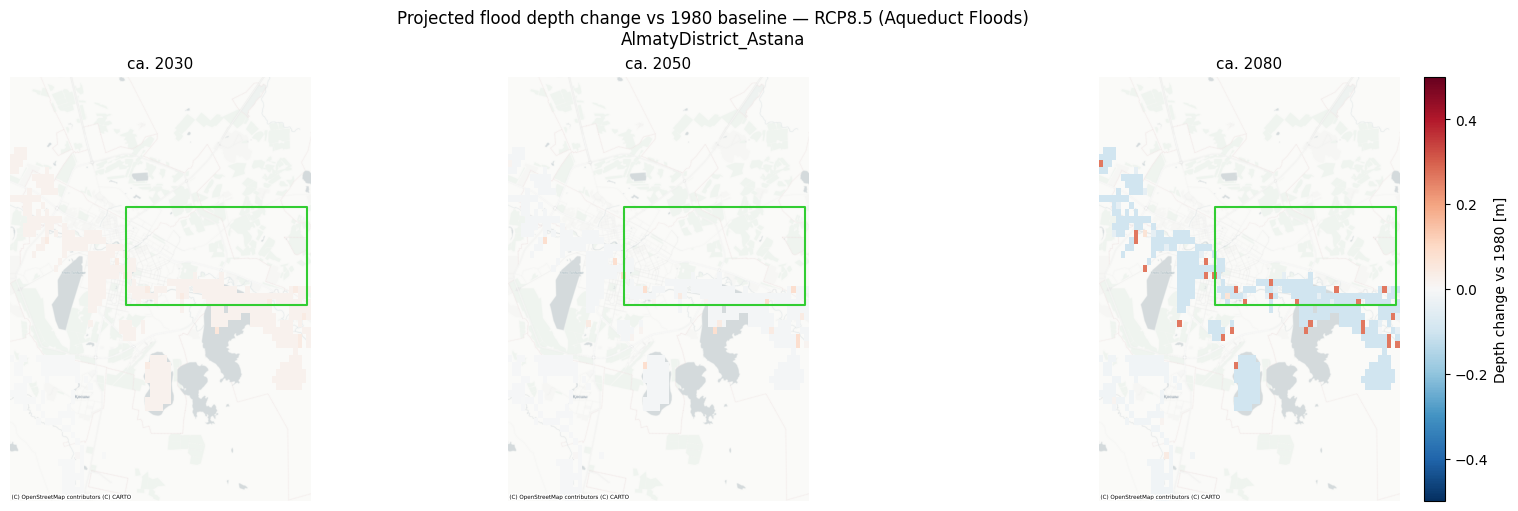

In [9]:
fig, axs = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True,
                        sharex=True, sharey=True)
for ii, year in enumerate(years_aq):
    diff = (aq_all['inun'].sel(year=year, scenario='rcp8p5').squeeze()
            - aq_base['inun'].squeeze())
    last = ii == 2
    diff.plot(ax=axs[ii], cmap='RdBu_r', vmin=-0.5, vmax=0.5,
              add_colorbar=last,
              cbar_kwargs={'label': 'Depth change vs 1980 [m]'} if last else {})
    outline.plot(ax=axs[ii], edgecolor='limegreen', facecolor='none',
                 linewidth=1.5, zorder=5)
    ctx.add_basemap(axs[ii], crs='EPSG:4326',
                    source=ctx.providers.CartoDB.Positron, attribution_size=4)
    axs[ii].set_title(f'ca. {year}', fontsize=11)
    axs[ii].set_axis_off()
fig.suptitle(
    f'Projected flood depth change vs 1980 baseline — RCP8.5 (Aqueduct Floods)\n{save_name}',
    fontsize=12)
fig.savefig(report_dir / 'fig03_projected_change_rcp85.png', dpi=150, bbox_inches='tight')
plt.show()

# Scenario Comparison — Projected Mean Depth Change

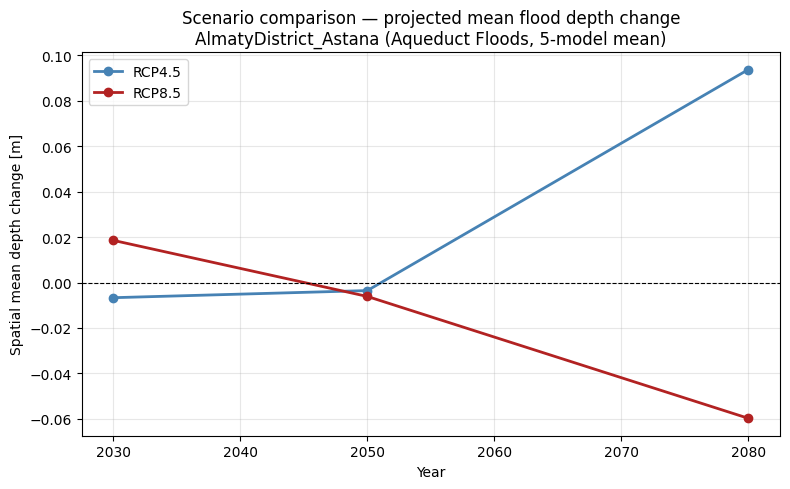

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
for scen in scenarios:
    diffs = [
        float((aq_all['inun'].sel(year=y, scenario=scen).squeeze()
               - aq_base['inun'].squeeze()).mean(skipna=True))
        for y in years_aq
    ]
    ax.plot(years_aq, diffs, marker='o', label=scen_labels[scen],
            color=scen_colors[scen], linewidth=2)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Year')
ax.set_ylabel('Spatial mean depth change [m]')
ax.set_title(
    f'Scenario comparison — projected mean flood depth change\n'
    f'{save_name} (Aqueduct Floods, 5-model mean)')
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(report_dir / 'fig04_scenario_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Building Damage Map — RP100

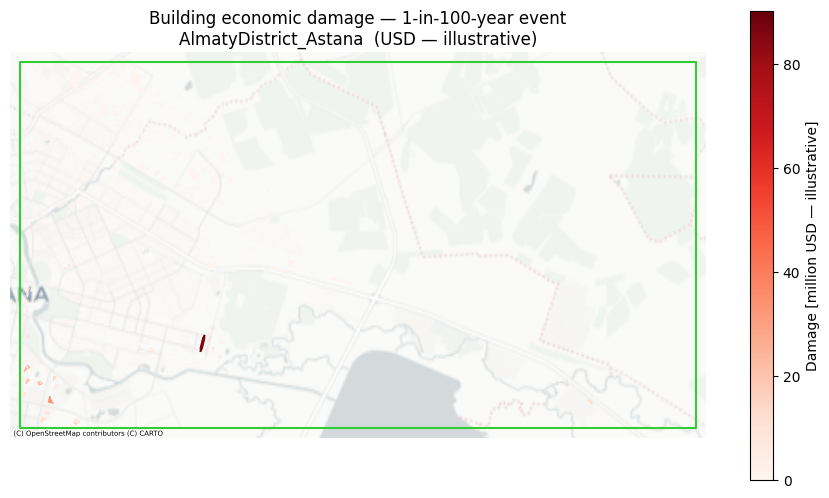

In [11]:
shp_100 = gpd.read_file(dmg_dir / f'{save_name}_Depths_Building_RP100.shp')

fig, ax = plt.subplots(figsize=(9, 7))
shp_100.plot(column='TotDamage', cmap='Reds', ax=ax, legend=True,
             legend_kwds={'label': 'Damage [million USD — illustrative]', 'shrink': 0.7},
             missing_kwds={'color': 'lightgrey'})
outline.plot(ax=ax, edgecolor='limegreen', facecolor='none', linewidth=1.5, zorder=5)
ax.set_xlim(Longitude1 - xbuffer, Longitude2 + xbuffer)
ax.set_ylim(Latitude1  - ybuffer, Latitude2  + ybuffer)
ctx.add_basemap(ax, crs='EPSG:4326',
                source=ctx.providers.CartoDB.Positron, attribution_size=5)
ax.set_title(f'Building economic damage — 1-in-100-year event\n{save_name}  (USD — illustrative)')
ax.set_axis_off()
fig.tight_layout()
fig.savefig(report_dir / 'fig05_building_damage_rp100.png', dpi=150, bbox_inches='tight')
plt.show()

# Damage by Building Class and Return Period

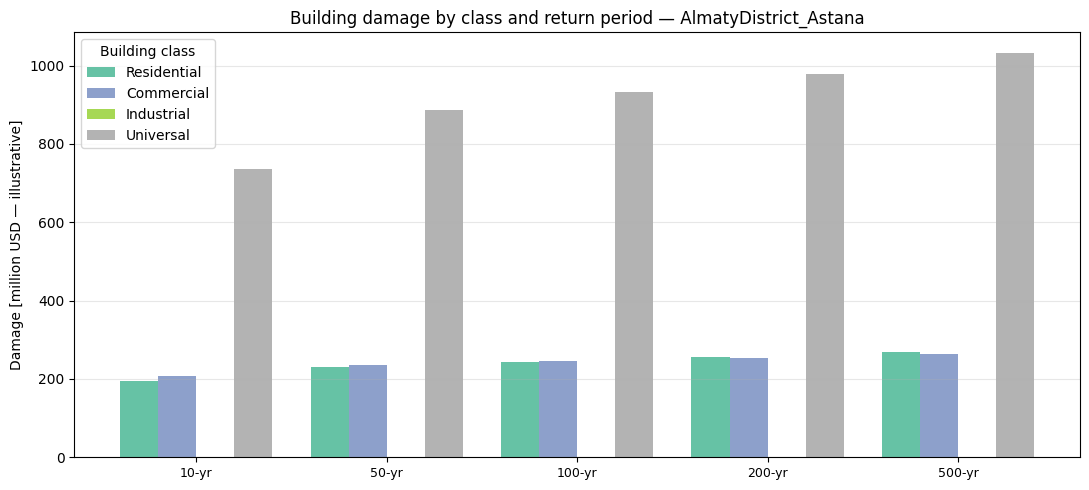

In [12]:
dm_vals = dmg_csv.loc[classes, rp_cols] / 1e6   # USD -> million USD
x       = np.arange(len(rp_cols))
width   = 0.8 / len(classes)
colors  = plt.cm.Set2(np.linspace(0, 0.9, len(classes)))

fig, ax = plt.subplots(figsize=(11, 5))
for i, cls in enumerate(classes):
    ax.bar(x + i * width - 0.4 + width / 2, dm_vals.loc[cls], width,
           label=cls, color=colors[i])
ax.set_xticks(x)
ax.set_xticklabels(rp_cols, fontsize=9)
ax.set_ylabel('Damage [million USD — illustrative]')
ax.set_title(f'Building damage by class and return period — {save_name}')
ax.legend(title='Building class')
ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
fig.savefig(report_dir / 'fig06_damage_by_class.png', dpi=150, bbox_inches='tight')
plt.show()

# Building Damage-Exceedance Curve and Expected Annual Damage

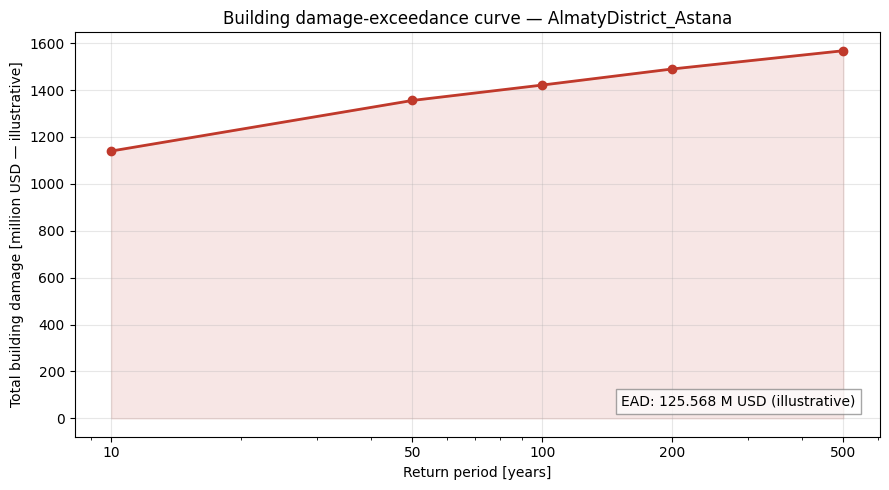

In [13]:
ead = float(sum(
    (probs[i] - probs[i + 1]) * (totals[i] + totals[i + 1]) / 2
    for i in range(len(return_periods) - 1)
))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(return_periods, totals, marker='o', color='#c0392b', linewidth=2)
ax.fill_between(return_periods, 0, totals, alpha=0.12, color='#c0392b')
ax.set_xscale('log')
ax.set_xticks(return_periods)
ax.set_xticklabels(return_periods)
ax.set_xlabel('Return period [years]')
ax.set_ylabel('Total building damage [million USD — illustrative]')
ax.set_title(f'Building damage-exceedance curve — {save_name}')
ax.text(0.97, 0.07, f'EAD: {ead:.3f} M USD (illustrative)',
        transform=ax.transAxes, ha='right', va='bottom', fontsize=10,
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='grey'))
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(report_dir / 'fig07_damage_exceedance.png', dpi=150, bbox_inches='tight')
plt.show()

# Population Exposure and Displacement by Return Period

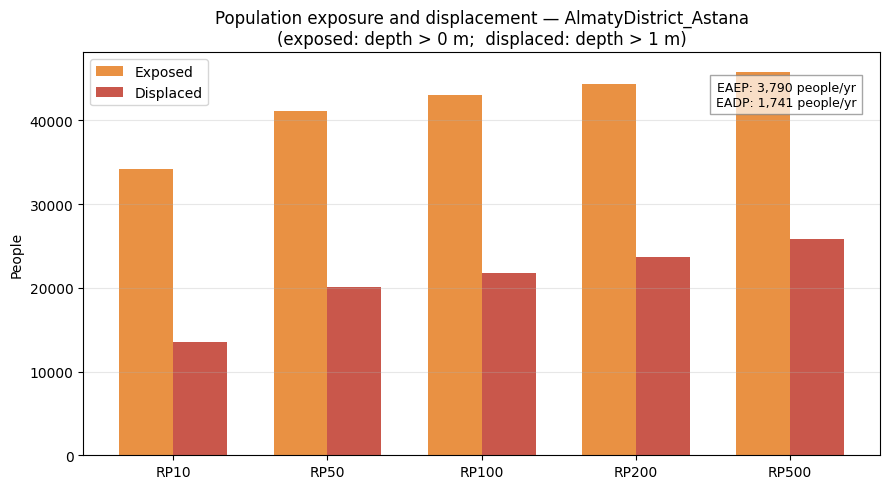

In [14]:
probs_pop = 1 / np.array(pop_csv['Return Period (yr)'], dtype=float)
exp_vals  = pop_csv['Exposed Population'].values
dis_vals  = pop_csv['Displaced Population'].values
eaep = float(sum((probs_pop[i] - probs_pop[i+1]) * (exp_vals[i] + exp_vals[i+1]) / 2
                 for i in range(len(probs_pop) - 1)))
eadp = float(sum((probs_pop[i] - probs_pop[i+1]) * (dis_vals[i] + dis_vals[i+1]) / 2
                 for i in range(len(probs_pop) - 1)))

x  = np.arange(len(return_periods))
w  = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - w / 2, exp_vals, w, label='Exposed',   color='#e67e22', alpha=0.85)
ax.bar(x + w / 2, dis_vals, w, label='Displaced', color='#c0392b', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels([f'RP{rp}' for rp in return_periods])
ax.set_ylabel('People')
ax.set_title(
    f'Population exposure and displacement — {save_name}\n'
    '(exposed: depth > 0 m;  displaced: depth > 1 m)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.text(0.97, 0.93,
        f'EAEP: {round(eaep):,} people/yr\nEADP: {round(eadp):,} people/yr',
        transform=ax.transAxes, ha='right', va='top', fontsize=9,
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='grey'))
fig.tight_layout()
fig.savefig(report_dir / 'fig08_population_exposure.png', dpi=150, bbox_inches='tight')
plt.show()

# OSM Building Classification Map

C:\Users\dauzo\AppData\Local\Temp\ipykernel_21816\4290166492.py:11: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(title='Building class', loc='upper right', fontsize=9)
C:\Users\dauzo\AppData\Local\Temp\ipykernel_21816\4290166492.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='Building class', loc='upper right', fontsize=9)


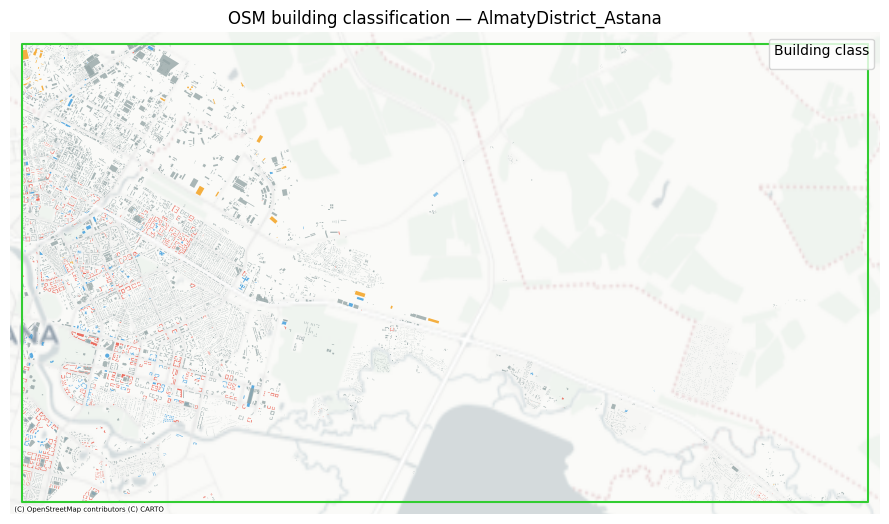

In [15]:
fig, ax = plt.subplots(figsize=(9, 7))
for cls, color in class_colors.items():
    sub = osm_gdf[osm_gdf['bldgClass'] == cls]
    if len(sub):
        sub.plot(ax=ax, facecolor=color, edgecolor='none', alpha=0.8, label=cls)
outline.plot(ax=ax, edgecolor='limegreen', facecolor='none', linewidth=1.5, zorder=5)
ax.set_xlim(Longitude1 - xbuffer, Longitude2 + xbuffer)
ax.set_ylim(Latitude1  - ybuffer, Latitude2  + ybuffer)
ctx.add_basemap(ax, crs='EPSG:4326',
                source=ctx.providers.CartoDB.Positron, attribution_size=5)
ax.legend(title='Building class', loc='upper right', fontsize=9)
ax.set_title(f'OSM building classification — {save_name}')
ax.set_axis_off()
fig.tight_layout()
fig.savefig(report_dir / 'fig09_building_classification.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary Infographic Panel

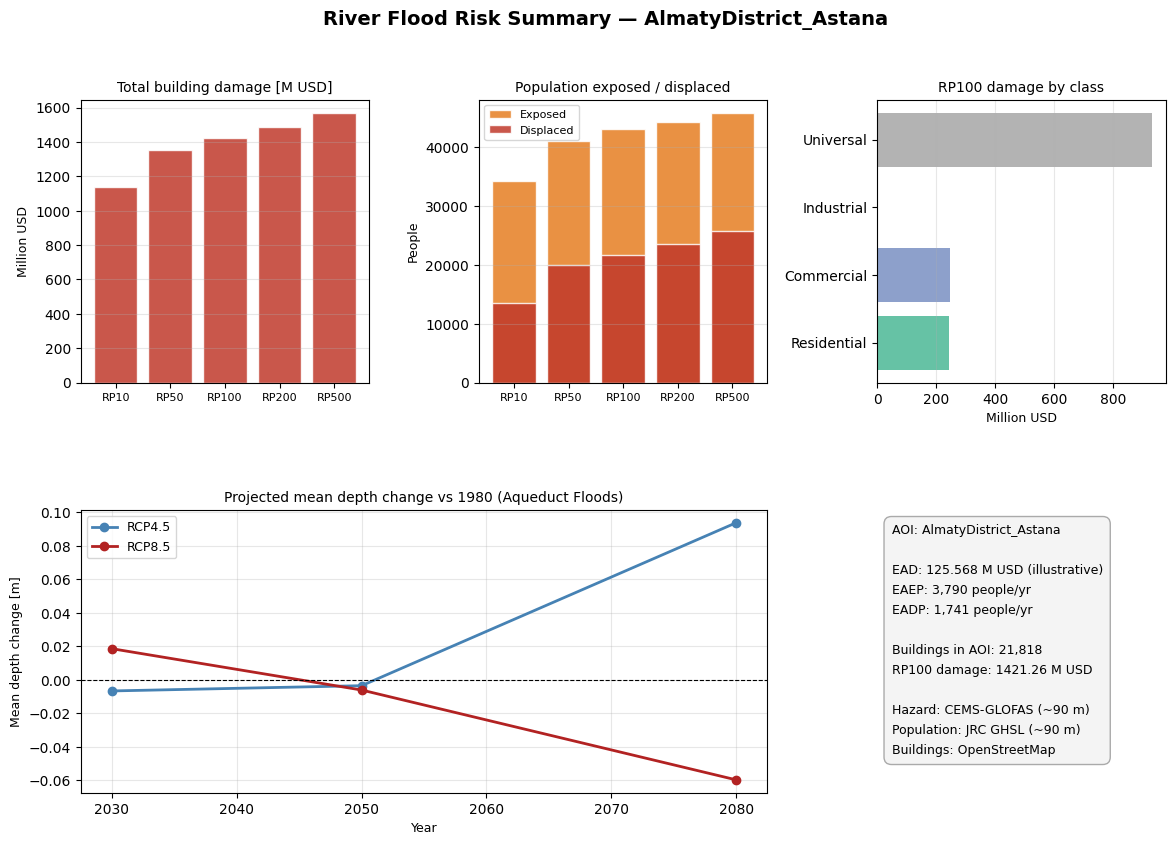

All report figures saved to: results\Astana\report


In [16]:
rp100_idx  = return_periods.index(100)
n_bldgs    = len(shp_100)
cls_rp100  = (dmg_csv.loc[classes, f'{100}-yr'] / 1e6).clip(lower=0)
colors_bar = plt.cm.Set2(np.linspace(0, 0.9, len(cls_rp100)))

fig = plt.figure(figsize=(14, 9))
gs  = mgs.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)

ax_a = fig.add_subplot(gs[0, 0])
ax_a.bar([f'RP{rp}' for rp in return_periods], totals,
         color='#c0392b', alpha=0.85, edgecolor='white')
ax_a.set_title('Total building damage [M USD]', fontsize=10)
ax_a.set_ylabel('Million USD', fontsize=9)
ax_a.tick_params(axis='x', labelsize=8)
ax_a.grid(axis='y', alpha=0.3)

ax_b = fig.add_subplot(gs[0, 1])
ax_b.bar([f'RP{rp}' for rp in return_periods], exp_vals,
         color='#e67e22', alpha=0.85, edgecolor='white', label='Exposed')
ax_b.bar([f'RP{rp}' for rp in return_periods], dis_vals,
         color='#c0392b', alpha=0.85, edgecolor='white', label='Displaced')
ax_b.set_title('Population exposed / displaced', fontsize=10)
ax_b.set_ylabel('People', fontsize=9)
ax_b.legend(fontsize=8)
ax_b.tick_params(axis='x', labelsize=8)
ax_b.grid(axis='y', alpha=0.3)

ax_c = fig.add_subplot(gs[0, 2])
ax_c.barh(cls_rp100.index, cls_rp100.values, color=colors_bar)
ax_c.set_xlabel('Million USD', fontsize=9)
ax_c.set_title('RP100 damage by class', fontsize=10)
ax_c.grid(axis='x', alpha=0.3)

ax_d = fig.add_subplot(gs[1, :2])
for scen in scenarios:
    diffs = [
        float((aq_all['inun'].sel(year=y, scenario=scen).squeeze()
               - aq_base['inun'].squeeze()).mean(skipna=True))
        for y in years_aq
    ]
    ax_d.plot(years_aq, diffs, marker='o', label=scen_labels[scen],
              color=scen_colors[scen], linewidth=2)
ax_d.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax_d.set_xlabel('Year', fontsize=9)
ax_d.set_ylabel('Mean depth change [m]', fontsize=9)
ax_d.set_title('Projected mean depth change vs 1980 (Aqueduct Floods)', fontsize=10)
ax_d.legend(fontsize=9)
ax_d.grid(alpha=0.3)

ax_e = fig.add_subplot(gs[1, 2])
ax_e.axis('off')
stats_lines = [
    f'AOI: {save_name}',
    '',
    f'EAD: {ead:.3f} M USD (illustrative)',
    f'EAEP: {round(eaep):,} people/yr',
    f'EADP: {round(eadp):,} people/yr',
    '',
    f'Buildings in AOI: {n_bldgs:,}',
    f'RP100 damage: {totals[rp100_idx]:.2f} M USD',
    '',
    'Hazard: CEMS-GLOFAS (~90 m)',
    'Population: JRC GHSL (~90 m)',
    'Buildings: OpenStreetMap',
]
ax_e.text(0.05, 0.95, '\n'.join(stats_lines), transform=ax_e.transAxes,
          va='top', fontsize=9, linespacing=1.7,
          bbox=dict(facecolor='#f4f4f4', edgecolor='#aaaaaa', boxstyle='round,pad=0.6'))

fig.suptitle(f'River Flood Risk Summary — {save_name}',
             fontsize=14, fontweight='bold')
fig.savefig(report_dir / 'fig10_summary_infographic.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'All report figures saved to: {report_dir}')